💡 **Environment:** `clamp-analyses` (R kernel)

Figure 3 is exported at **180 × 170 mm**, with all text at least **5 pt** at final size.
Nature Methods specifies a maximum width of 180 mm and 5–7 pt text:
https://www.nature.com/nmeth/submission-guidelines/aip-and-formatting
The linked Nature figure guide specifies a maximum figure height of 170 mm:
https://research-figure-guide.nature.com/figures/building-and-exporting-figure-panels/

B and D both use CLAMPbase from the completed main-branch trait-recovery summaries; H uses the current four-method
`three_model_comparison/data` exports, including Gene-based; I uses the source tables
from main's `04_crispercas/02_network.ipynb` (main commit `d93f710`).
F displays only 75% vs 25% and 50%; BH adjustment retains the full original comparison family.
All plotted source tables are exported to `output/99_panels/fig3/source_data`.


In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
  library(patchwork)
  library(cowplot)
  library(ggrastr)
  library(ggpubr)
  library(yaml)
  library(here)
})


In [2]:
cfg <- yaml::read_yaml(here("config.yaml"))

FS_TAG          <- 7
FS_TITLE        <- 6.5
FS_AXIS_TITLE   <- 5.5
FS_AXIS_TEXT    <- 5
FS_LEGEND       <- 5
FS_LEGEND_TITLE <- 5.5

FIG_W <- 180
FIG_H <- 170
stopifnot(FIG_W == 180, FIG_H == 170)

DATA_DIR <- here("output/03_model_biology/02_archs4")

MODEL_COLORS <- unlist(cfg$MODEL_COLORS, use.names = TRUE)
# CLAMPfull is the canonical ARCHS4 model; CLAMPbase is the ARCHS4
# coverage model used in Panel A. Both colours are defined in config.yaml.
ARCHS4_MODEL_COLORS   <- MODEL_COLORS[c("CLAMPfull", "CLAMPbase")]
ARCHS4_DATASET_COLORS <- c(ARCHS4 = "#0072B2", GTEx = "#E69F00", recount2 = "#009E73")
DATASET_NAMES <- c(archs4 = "ARCHS4", gtex = "GTEx", recount2 = "recount2")

theme_nm <- function(base_size = FS_AXIS_TEXT, base_line_size = 0.25) {
  theme_classic(base_size = base_size, base_family = "Helvetica") %+replace%
    theme(
      axis.line = element_line(linewidth = base_line_size, colour = "black"),
      axis.ticks = element_line(linewidth = base_line_size, colour = "black"),
      axis.ticks.length = unit(1.1, "mm"),
      axis.text = element_text(size = FS_AXIS_TEXT, colour = "black"),
      axis.title = element_text(size = FS_AXIS_TITLE, face = "plain", colour = "black"),
      legend.text = element_text(size = FS_LEGEND),
      legend.title = element_text(size = FS_LEGEND_TITLE, face = "plain"),
      legend.key = element_blank(),
      legend.background = element_blank(),
      strip.background = element_blank(),
      strip.text = element_text(size = FS_TITLE, face = "bold", margin = margin(b = 0.7)),
      panel.grid = element_blank(),
      plot.margin = margin(1.3, 1.3, 1.3, 1.3)
    )
}

add_tag <- function(p, label, x = 0.002, y = 0.998) {
  ggdraw() +
    draw_plot(p, x = 0.015, y = 0, width = 0.985, height = 0.94) +
    draw_label(label, x = x, y = y, hjust = 0, vjust = 1,
               size = FS_TAG, fontface = "bold", fontfamily = "Helvetica")
}

# Panels without a producing pipeline yet (projections, CRISPR-Cas9) get a
# bordered empty box with just the panel title.
placeholder_panel <- function(title) {
  ggplot() +
    theme_void(base_size = FS_AXIS_TEXT) +
    labs(title = title) +
    theme(
      plot.title = element_text(size = FS_TITLE, face = "bold", hjust = 0.5,
                                margin = margin(b = 1.2)),
      panel.border = element_rect(colour = "grey70", fill = NA, linewidth = 0.3),
      plot.margin = margin(1.3, 1.3, 1.3, 1.3)
    )
}

set.seed(1)
source_dir <- here("output/99_panels/fig3/source_data")
dir.create(source_dir, recursive=TRUE, showWarnings=FALSE)


## Panel A: ARCHS4 pathway coverage vs. sample fraction (CLAMPbase)

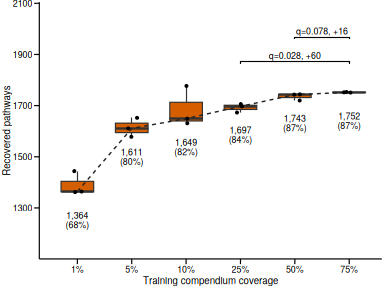

In [3]:
# Follows 00_coverage.ipynb's "ARCHS4 coverage by sample fraction" cell:
# databases pooled (reactome dropped, matching the pinned GO:BP-prior
# evaluation), CLAMPbase, boxplot + jitter + dashed median line, with the
# 25%/50% vs. 75% paired-seed significance brackets.
coverage_long <- fread(file.path(DATA_DIR, "00_coverage", "coverage_long.csv"))
coverage_long <- coverage_long[database != "reactome"]
FDR <- unique(coverage_long$fdr)
stopifnot(length(FDR) == 1L)

arch <- coverage_long[dataset == "archs4" & fraction < 100 & model == "CLAMPbase"]
arch_sum <- arch[, .(
  recovered_pathways = sum(recovered_pathways),
  eligible_pathways  = sum(eligible_pathways)
), by = .(fraction, seed)]
arch_sum[, fraction_label := factor(fraction, levels = sort(unique(fraction)),
                                     labels = sprintf("%s%%", sort(unique(fraction))))]

fraction_totals <- arch_sum[, .(
  recovered_pathways = as.integer(round(median(recovered_pathways))),
  eligible_pathways  = as.integer(round(median(eligible_pathways)))
), by = fraction]
fraction_totals[, fraction_label := factor(sprintf("%s%%", fraction),
                                           levels = levels(arch_sum$fraction_label))]
fraction_totals[, label := sprintf("%s\n(%.0f%%)", format(recovered_pathways, big.mark = ",", trim = TRUE),
                                   100 * recovered_pathways / eligible_pathways)]
fraction_totals[, label_y := recovered_pathways - 0.19 * diff(range(arch_sum$recovered_pathways))]

comparisons_A <- rbindlist(lapply(c(25L, 50L), function(fv) {
  ref  <- arch_sum[fraction == 75L][order(seed)]$recovered_pathways
  cand <- arch_sum[fraction == fv][order(seed)]$recovered_pathways
  data.table(group1 = sprintf("%s%%", fv), group2 = "75%",
             p = t.test(ref, cand, paired = TRUE, alternative = "greater")$p.value,
             difference = as.integer(round(mean(ref - cand))))
}))
comparisons_A[, p.adj := p.adjust(p, method = "BH")]
comparisons_A[, y.position := max(arch_sum$recovered_pathways) +
                seq_len(.N) * diff(range(arch_sum$recovered_pathways)) * 0.23]
comparisons_A[, label := sprintf("q=%.3f, %+d", p.adj, difference)]

plot_A <- ggplot(arch_sum, aes(fraction_label, recovered_pathways)) +
  geom_boxplot(fill = ARCHS4_MODEL_COLORS[["CLAMPbase"]], width = 0.6, outlier.shape = NA,
               linewidth = 0.25) +
  stat_summary(aes(group = 1), fun = median, geom = "line", linetype = "dashed",
               colour = "#222222", linewidth = 0.3) +
  geom_jitter(width = 0.10, height = 0, size = 0.5) +
  geom_text(data = fraction_totals, aes(fraction_label, label_y, label = label),
            inherit.aes = FALSE, size = 5/ggplot2::.pt, vjust=1, lineheight=.95) +
  ggpubr::stat_pvalue_manual(comparisons_A, label = "label", tip.length = 0.01, size = 5/ggplot2::.pt,
                              bracket.size = 0.25) +
  scale_y_continuous(expand = expansion(mult = c(0.27, 0.20))) +
  scale_x_discrete(expand = expansion(add = c(0.7, 0.6))) +
  labs(x = "Training compendium coverage",
       y = "Recovered pathways") +
  theme_nm()

options(repr.plot.width = 3.2, repr.plot.height = 2.4)
print(plot_A)


## Panel B: ARCHS4 trait coverage vs. sample fraction (CLAMPbase)


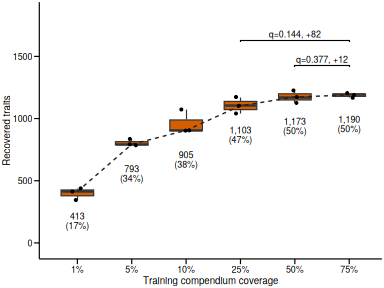

In [4]:
# Use the completed main-branch coverage summary (fixed trait catalog).
trait_sum <- fread(file.path(DATA_DIR, "00_coverage/coverage_trait_recovery.csv"))[model == "CLAMPbase" & fraction < 100]
stopifnot(nrow(trait_sum) > 0, all(trait_sum$fdr == FDR))
fwrite(trait_sum, file.path(source_dir, "B_trait_recovery.csv"))
trait_sum[, fraction_label := factor(fraction, levels = sort(unique(fraction)),
                                      labels = sprintf("%s%%", sort(unique(fraction))))]

trait_totals <- trait_sum[, .(
  recovered_traits = as.integer(round(median(recovered_traits))),
  eligible_traits  = unique(eligible_traits)
), by = fraction]
trait_totals[, fraction_label := factor(sprintf("%s%%", fraction),
                                        levels = levels(trait_sum$fraction_label))]
trait_totals[, label := sprintf("%s\n(%.0f%%)", format(recovered_traits, big.mark = ",", trim = TRUE),
                                100 * recovered_traits / eligible_traits)]
trait_totals[, label_y := recovered_traits - 0.19 * diff(range(trait_sum$recovered_traits))]

seed_counts <- trait_sum[, .(n = uniqueN(seed)), by = fraction]
tiers <- list(
  list(ref = 75L, cands = c(50L, 25L)), list(ref = 50L, cands = c(25L, 10L)),
  list(ref = 25L, cands = c(10L, 5L, 1L)), list(ref = 10L, cands = c(5L, 1L)),
  list(ref = 5L,  cands = c(1L))
)
chosen_tier <- Find(function(t) isTRUE(seed_counts[fraction == t$ref, n] >= 2L), tiers)

trait_comparisons <- if (!is.null(chosen_tier)) {
  REF_FRACTION <- chosen_tier$ref
  ref_seeds <- trait_sum[fraction == REF_FRACTION, seed]
  rbindlist(lapply(chosen_tier$cands, function(fv) {
    if (!fv %in% trait_sum$fraction) return(NULL)
    common <- intersect(ref_seeds, trait_sum[fraction == fv, seed])
    if (length(common) < 2L) return(NULL)
    ref  <- trait_sum[fraction == REF_FRACTION][seed %in% common][order(seed)]$recovered_traits
    cand <- trait_sum[fraction == fv][seed %in% common][order(seed)]$recovered_traits
    data.table(group1 = sprintf("%s%%", fv), group2 = sprintf("%s%%", REF_FRACTION),
               p = t.test(ref, cand, paired = TRUE, alternative = "greater")$p.value,
               difference = as.integer(round(mean(ref - cand))))
  }), fill = TRUE)
} else data.table()
if (nrow(trait_comparisons)) {
  trait_comparisons[, p.adj := p.adjust(p, method = "BH")]
  trait_comparisons[, y.position := max(trait_sum$recovered_traits) +
                      seq_len(.N) * diff(range(trait_sum$recovered_traits)) * 0.23]
  trait_comparisons[, label := sprintf("q=%.3f, %+d", p.adj, difference)]
}

plot_B <- ggplot(trait_sum, aes(fraction_label, recovered_traits)) +
  geom_boxplot(fill = ARCHS4_MODEL_COLORS[["CLAMPbase"]], width = 0.6, outlier.shape = NA,
               linewidth = 0.25) +
  stat_summary(aes(group = 1), fun = median, geom = "line", linetype = "dashed",
               colour = "#222222", linewidth = 0.3) +
  geom_jitter(width = 0.10, height = 0, size = 0.5) +
  geom_text(data = trait_totals, aes(fraction_label, label_y, label = label),
            inherit.aes = FALSE, size = 5/ggplot2::.pt, vjust=1, lineheight=.95) +
  scale_y_continuous(expand = expansion(mult = c(0.27, 0.22))) +
  scale_x_discrete(expand = expansion(add = c(0.7, 0.6))) +
  labs(x = "Training compendium coverage",
       y = "Recovered traits") +
  theme_nm()
if (nrow(trait_comparisons)) {
  plot_B <- plot_B + ggpubr::stat_pvalue_manual(trait_comparisons, label = "label",
                                                tip.length = 0.01, size = 5/ggplot2::.pt, bracket.size = 0.25)
}

options(repr.plot.width = 3.2, repr.plot.height = 2.4)
print(plot_B)

fwrite(trait_comparisons, file.path(source_dir, "B_paired_tests.csv"))


## Panel C: pathway coverage across compendia, full data (CLAMPbase)

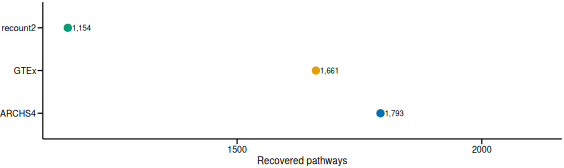

In [5]:
# Follows 00_coverage.ipynb's "Full-data comparison" cell: one point per
# compendium, pathways pooled across the 2 ORA databases, one model per
# dataset (seed 1 for ARCHS4/CLAMPfull, seed 0 for the GTEx/recount2
# CLAMPbase comparators).
cross <- coverage_long[fraction == 100 & (
  (model == "CLAMPfull" & seed == 1L) |
  (model == "CLAMPbase" & ((dataset == "archs4" & seed == 1L) | (dataset != "archs4" & seed == 0L)))
)]
cross_sum_c <- cross[model == "CLAMPbase", .(recovered_pathways = sum(recovered_pathways)), by = dataset]
cross_sum_c[, dataset_label := factor(DATASET_NAMES[dataset],
                                      levels = DATASET_NAMES[c("archs4", "gtex", "recount2")])]
cross_sum_c[, label := format(recovered_pathways, big.mark = ",", trim = TRUE)]

plot_C <- ggplot(cross_sum_c, aes(recovered_pathways, dataset_label, colour = dataset_label)) +
  geom_point(size = 1.7) +
  geom_text(aes(label = label), hjust = -0.22, colour = "black", size = 1.5) +
  scale_colour_manual(values = ARCHS4_DATASET_COLORS, guide = "none") +
  scale_x_continuous(breaks=scales::breaks_pretty(n=2), expand = expansion(mult = c(0.08, 0.58))) +
  labs(x = "Recovered pathways", y = NULL) +
  theme_nm()

options(repr.plot.width = 4.7, repr.plot.height = 1.4)
print(plot_C)


## Panel D: trait coverage across compendia, full data (CLAMPbase)

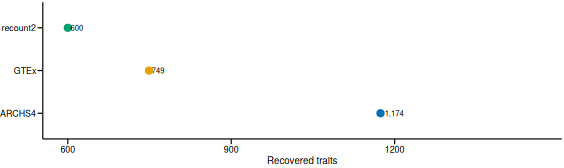

In [6]:
# Use the full-compendium results uploaded with the trait report on main.
final_sum <- fread(file.path(DATA_DIR, "00_coverage/final_trait_recovery.csv"))[model == "CLAMPbase"]
stopifnot(setequal(final_sum$dataset, names(DATASET_NAMES)), all(final_sum$fdr == FDR))
fwrite(final_sum, file.path(source_dir, "D_trait_recovery.csv"))
final_sum[, dataset_label := factor(DATASET_NAMES[dataset],
                                    levels = DATASET_NAMES[c("archs4", "gtex", "recount2")])]
final_sum[, label := format(recovered_traits, big.mark = ",", trim = TRUE)]

plot_D <- ggplot(final_sum, aes(recovered_traits, dataset_label, colour = dataset_label)) +
  geom_point(size = 1.7) +
  geom_text(aes(label = label), hjust = -0.22, colour = "black", size = 1.5) +
  scale_colour_manual(values = ARCHS4_DATASET_COLORS, guide = "none") +
  # Explicit breaks: the 0.58 right expansion leaves the largest pretty break
  # (1500) sitting on the panel edge, where cowplot clips its label.
  scale_x_continuous(breaks = c(600, 900, 1200), expand = expansion(mult = c(0.08, 0.58))) +
  labs(x = "Recovered traits", y = NULL) +
  theme_nm()

options(repr.plot.width = 4.7, repr.plot.height = 1.4)
print(plot_D)


## Panel E: saturation vs. rank K (CLAMPbase)

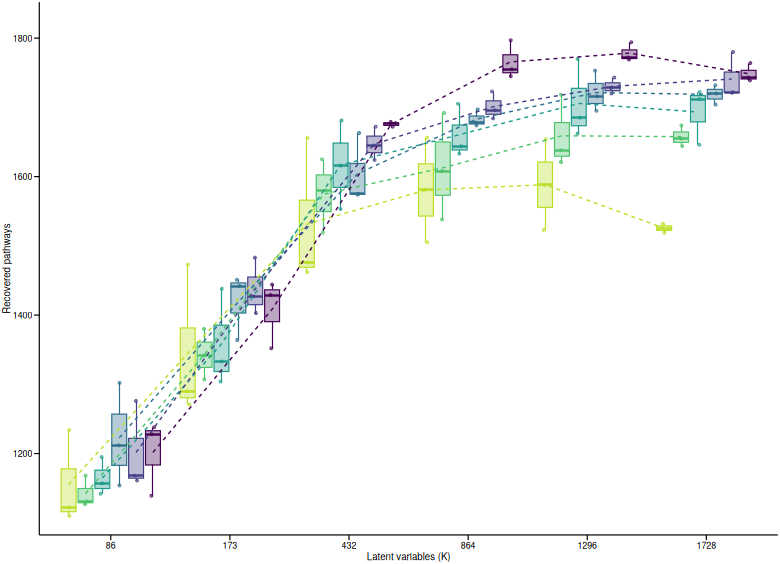

In [7]:
# Follows the archs4_saturation branch's 00_saturation.ipynb make_k_plot():
# databases pooled, boxplot + jittered points dodged by subsampling
# fraction at each K, with a dashed mean line per fraction across K.
saturation_long <- fread(file.path(DATA_DIR, "01_saturation", "saturation_long.csv"))
saturation_long <- saturation_long[database != "reactome"]

sat <- saturation_long[dataset == "archs4" & model == "CLAMPbase", .(
  recovered_pathways = sum(recovered_pathways),
  eligible_pathways  = sum(eligible_pathways)
), by = .(fraction, k, seed)]
sat[, k_label := factor(k, levels = sort(unique(k)))]
sat[, fraction_label := factor(sprintf("%d%%", fraction),
                               levels = sprintf("%d%%", sort(unique(fraction))))]

DODGE_E <- position_dodge(width = 0.85)
dodge_offset <- function(g) {
  n <- nlevels(g)
  (as.integer(g) - (n + 1) / 2) * (0.85 / n)
}
means_E <- sat[, .(recovered_pathways = mean(recovered_pathways)), by = .(fraction_label, k_label)]
means_E[, x := as.integer(k_label) + dodge_offset(fraction_label)]

plot_E <- ggplot(sat, aes(k_label, recovered_pathways, fill = fraction_label, colour = fraction_label)) +
  geom_boxplot(position = DODGE_E, width = 0.75, outlier.shape = NA, alpha = 0.35, linewidth = 0.25) +
  geom_point(position = position_jitterdodge(jitter.width = 0.12, dodge.width = 0.85),
             size = 0.5, alpha = 0.65, show.legend = FALSE) +
  geom_line(data = means_E, aes(x = x, group = fraction_label),
            linetype = "dashed", linewidth = 0.3, show.legend = FALSE) +
  scale_fill_viridis_d(end = 0.9, direction = -1) +
  scale_colour_viridis_d(end = 0.9, direction = -1) +
  scale_y_continuous(expand = expansion(mult = c(0.04, 0.08))) +
  labs(x = "Latent variables (K)", y = "Recovered pathways",
       fill = "Studies used", colour = "Studies used") +
  theme_nm() +
  theme(legend.position = "none", legend.key.size = unit(2.5, "mm"))

options(repr.plot.width = 6.5, repr.plot.height = 4.7)
print(plot_E)


## Panel F: saturation reference test at largest K, vs. 75% (CLAMPbase)

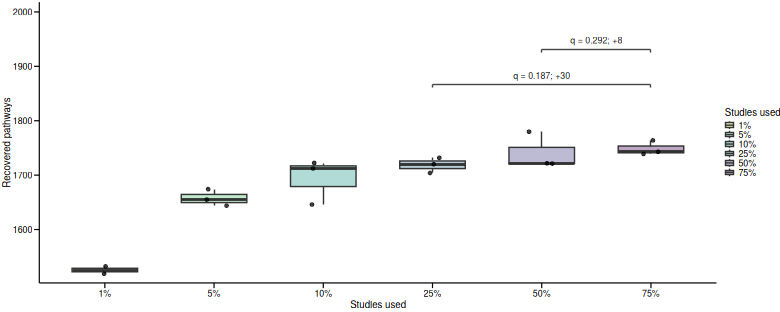

In [8]:
# Current main 00_saturation.ipynb: paired, one-sided greater tests,
# 75% versus 25% and 50%; BH correction across those two comparisons.
LAST_K <- max(sat$k)
REF_K  <- tail(levels(sat$fraction_label), 1L)

stars_for <- function(p) {
  ifelse(is.na(p), "n/a",
  ifelse(p < 0.001, "***",
  ifelse(p < 0.01, "**",
  ifelse(p < 0.05, "*", "ns"))))
}

sat_lastk <- droplevels(sat[k == LAST_K])
y_ref <- sat_lastk[fraction_label == REF_K][order(seed)]$recovered_pathways
others_F <- intersect(c("25%", "50%"), levels(sat_lastk$fraction_label))
ref_tests_F <- rbindlist(lapply(others_F, function(f) {
  x <- sat_lastk[fraction_label == f][order(seed)]$recovered_pathways
  if (length(x) < 2L || length(y_ref) < 2L) {
    return(data.table(fraction_label = f, n = length(x), n_ref = length(y_ref),
                       delta = NA_real_, p = NA_real_))
  }
  data.table(fraction_label = f, n = length(x), n_ref = length(y_ref),
             delta = mean(y_ref) - mean(x),
             p = t.test(y_ref, x, paired = TRUE, alternative = "greater")$p.value)
}))
ref_tests_F[, p_adj := p.adjust(p, method = "BH")]
ref_tests_F[, stars := stars_for(p_adj)]

lv_F <- levels(sat_lastk$fraction_label)
span_F <- range(sat_lastk$recovered_pathways)
yr_F <- diff(span_F)
st_F <- copy(ref_tests_F)[!is.na(delta) & fraction_label %in% c("25%","50%")][order(match(fraction_label, lv_F))]
st_F[, `:=`(x = match(as.character(fraction_label), lv_F), xend = match(REF_K, lv_F))]
st_F[, y := span_F[2] + yr_F * (0.08 + 0.25 * seq_len(.N))]
fmt_p_F <- function(p) ifelse(p < 0.001, sprintf("%.1e", p), sprintf("%.3f", p))
st_F[, label := sprintf("q = %s; %+.0f", fmt_p_F(p_adj), delta)]

plot_F <- ggplot(sat_lastk, aes(fraction_label, recovered_pathways, fill = fraction_label)) +
  geom_boxplot(width = 0.6, outlier.shape = NA, alpha = 0.35, linewidth = 0.3, show.legend = TRUE) +
  geom_jitter(width = 0.12, size = 0.7, alpha = 0.75, show.legend = FALSE) +
  geom_segment(data = st_F, aes(x = x, xend = xend, y = y, yend = y),
               inherit.aes = FALSE, colour = "#444444", linewidth = 0.3) +
  geom_segment(data = st_F, aes(x = x, xend = x, y = y, yend = y - yr_F * 0.02),
               inherit.aes = FALSE, colour = "#444444", linewidth = 0.3) +
  geom_segment(data = st_F, aes(x = xend, xend = xend, y = y, yend = y - yr_F * 0.02),
               inherit.aes = FALSE, colour = "#444444", linewidth = 0.3) +
  geom_text(data = st_F, aes(x = (x + xend) / 2, y = y + yr_F * 0.04, label = label),
            inherit.aes = FALSE, size = 5/ggplot2::.pt, vjust=0, colour = "#222222") +
  scale_fill_viridis_d(end = 0.9, direction = -1) +
  scale_y_continuous(expand = expansion(mult = c(0.04, 0.18))) +
  labs(x = "Studies used", y = "Recovered pathways", fill = "Studies used") +
  theme_nm() +
  theme(legend.position = "right", legend.key.size=unit(2,"mm"),
        legend.margin=margin(0,0,0,0)) + guides(fill=guide_legend(ncol=1, title.position="top"))

options(repr.plot.width = 6.5, repr.plot.height = 2.6)
print(plot_F)

fwrite(ref_tests_F,file.path(source_dir,"F_all_reference_tests.csv"))
fwrite(st_F,file.path(source_dir,"F_displayed_reference_tests.csv"))


## Panel H: canonical drug-disease pairs (three-model comparison)

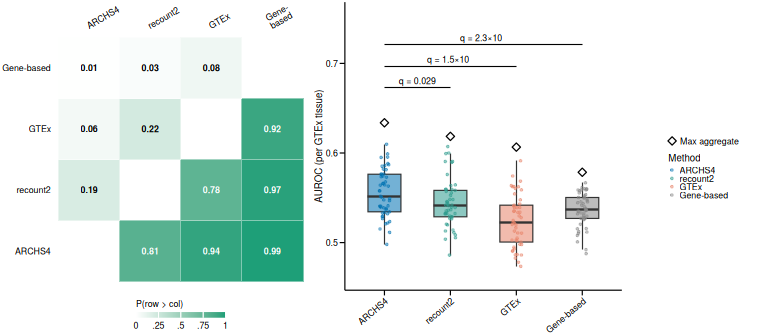

In [9]:
# Reuses the canonical drug-disease statistics from
# nbs/03_model_biology/02_archs4/02_drug_diseases_associations/
# 02_three_model_comparison.ipynb, translated from matplotlib into ggplot2.
ismb_dir <- file.path(DATA_DIR, "02_drug_diseases_canonical", "three_model_comparison", "data")
dd_order  <- c("ARCHS4", "recount2", "GTEx", "Gene-based")
# Match the ARCHS4 colour used for H's ARCHS4 projection gene points.
dd_colors <- c(ARCHS4 = unname(ARCHS4_MODEL_COLORS[["CLAMPfull"]]),
               recount2 = "#2E9B8E", GTEx = "#E8836B", `Gene-based` = "#888888")

dominance <- fread(file.path(ismb_dir, "ordering_stability.csv"))
tissue    <- fread(file.path(ismb_dir, "per_tissue_metrics.csv"))
agg_ref   <- fread(file.path(ismb_dir, "max_aggregate_reference.csv"))
tests     <- fread(file.path(ismb_dir, "paired_tissue_tests.csv"))
stopifnot(uniqueN(tissue$tissue) == 49, setequal(tissue$method, dd_order))

dom_long <- dominance[row_m != col_m]
dom_long[, row_m := factor(row_m, levels = dd_order)]
dom_long[, col_m := factor(col_m, levels = dd_order)]

plot_G1 <- ggplot(dom_long, aes(col_m, row_m, fill = value)) +
  geom_tile(color = "white") +
  geom_text(aes(label = sprintf("%.2f", value), color = value >= 0.7),
            size = 5/ggplot2::.pt, fontface = "bold", show.legend = FALSE) +
  scale_fill_gradient(low = "white", high = "#1B9E77", limits = c(0, 1),
                       name = "P(row > col)", guide=guide_colourbar(title.position="right",title.theme=element_text(angle=90,size=5),barwidth=unit(1.4,"mm"),barheight=unit(16,"mm")), breaks=c(0,.25,.5,.75,1), labels=c("0",".25",".5",".75","1")) +
  scale_color_manual(values = c("TRUE" = "white", "FALSE" = "black")) +
  scale_x_discrete(position = "top", labels=function(x) ifelse(x == "Gene-based", "Gene-\nbased", x)) +
  coord_fixed(ratio = 1) +
  labs(x = NULL, y = NULL) +
  theme_nm() +
  theme(axis.line = element_blank(), axis.ticks = element_blank(),
        axis.text.x = element_text(angle=30, hjust=0),
        legend.position = "right", legend.title = element_text(vjust = 1),
        legend.title.position="top",
        legend.key.width = unit(1.4, "mm"), legend.key.height = unit(3, "mm"))

tissue[, method := factor(method, levels = dd_order)]
agg_ref[, method := factor(method, levels = dd_order)]
top_y <- max(tissue$auroc, agg_ref$auroc)

tests_ord <- copy(tests[group1 == "ARCHS4" | group2 == "ARCHS4"])
tests_ord[, `:=`(xstart=match(group1,dd_order), xend=match(group2,dd_order))]

# 4-way legend: the 3 methods (shared fill/colour scale) plus the
# max-aggregate reference diamond, which had no legend entry at all before.
plot_G2 <- ggplot(tissue, aes(method, auroc)) +
  geom_boxplot(aes(fill = method), width = 0.5, outlier.shape = NA,
               alpha = 0.55, linewidth = 0.25, show.legend = FALSE) +
  geom_jitter(aes(color = method), width = 0.08, size = 0.4, alpha = 0.5) +
  geom_point(data = agg_ref, aes(x = method, y = auroc, shape = "Max aggregate"),
             size = 1.6, fill = "white", color = "black", stroke = 0.4) +
  scale_fill_manual(values = dd_colors, guide = "none") +
  scale_color_manual(values = dd_colors, name = "Method", breaks=dd_order) +
  scale_shape_manual(values = c("Max aggregate" = 23), name = NULL) +
  labs(x = NULL, y = "AUROC (per GTEx tissue)") +
  coord_cartesian(ylim = c(min(tissue$auroc, agg_ref$auroc) - 0.012, top_y + 0.12)) +
  theme_nm() +
  theme(legend.position = "right", legend.box = "vertical", legend.margin = margin(0,0,0,0),
        legend.key.size = unit(1.5, "mm"),
        axis.text.x=element_text(angle=40,hjust=1)) +
  guides(colour=guide_legend(ncol=1, title.position="top"), shape=guide_legend(nrow=1))

fmt_p_G <- function(p) {
  if (p >= .001) return(sprintf("%.3f",p))
  e <- floor(log10(p))
  sup <- c("⁰","¹","²","³","⁴","⁵","⁶","⁷","⁸","⁹")
  paste0(sprintf("%.1f",p/10^e),"×10⁻",paste0(sup[as.integer(strsplit(as.character(abs(e)),"")[[1]])+1],collapse=""))
}

for (i in seq_len(nrow(tests_ord))) {
  y <- top_y + 0.015 + 0.024 * i
  plot_G2 <- plot_G2 +
    annotate("segment", x = tests_ord$xstart[i], xend = tests_ord$xend[i], y = y, yend = y, linewidth = 0.25) +
    annotate("text", x = (tests_ord$xstart[i] + tests_ord$xend[i]) / 2, y = y + 0.004,
             label = sprintf("q = %s", fmt_p_G(tests_ord$q_value_bh[i])), size = 5/ggplot2::.pt, vjust=0)
}

# Keep G1's probability scale below its heatmap; only G2's key goes right.
plot_G1 <- plot_G1 + theme(legend.position="bottom",legend.title.position="top") +
  guides(fill=guide_colourbar(direction="horizontal",title.position="top",
    title.theme=element_text(angle=0,size=5),barwidth=unit(19,"mm"),barheight=unit(1.2,"mm")))
legend_G <- get_legend(plot_G2)
plot_G2 <- plot_G2 + theme(legend.position="none")
plot_G <- plot_grid(plot_G1, plot_G2, legend_G, nrow=1,rel_widths=c(1,1,.5))

options(repr.plot.width = 6.5, repr.plot.height = 2.8)
print(plot_G)

for (nm in c("ordering_stability", "per_tissue_metrics", "max_aggregate_reference", "paired_tissue_tests"))
  fwrite(fread(file.path(ismb_dir,paste0(nm,".csv"))), file.path(source_dir,paste0("G_",nm,".csv")))


## Panel G: cytokine (IFN-alpha) projection vs. local model -- paper-defined mechanism recovery (H1) and ISG-core gene ranking (H2)


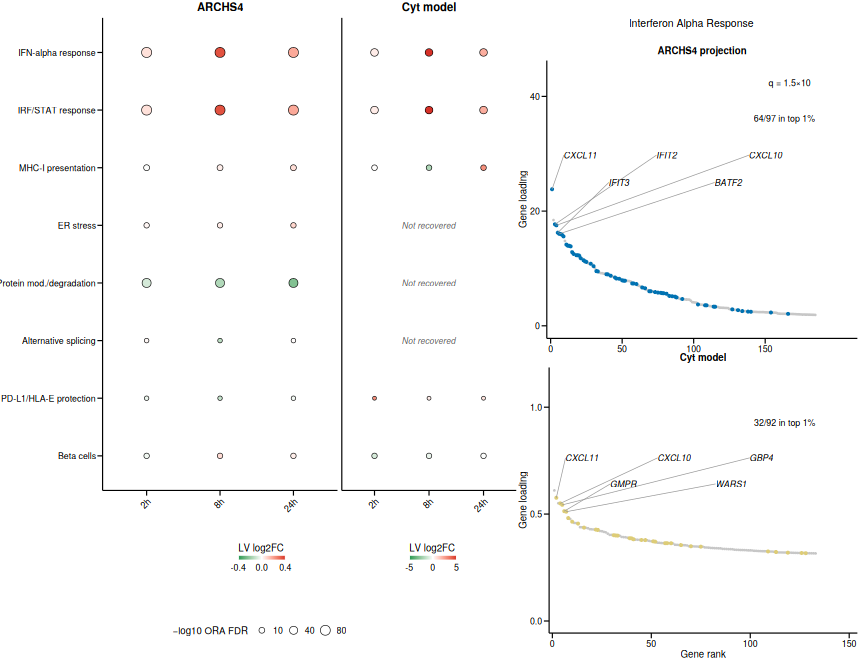

In [10]:
# Follows nbs/03_model_biology/02_archs4/03_projections/00_cytokines.ipynb:
# the paper-defined-mechanism dotplot (H1) and the ISG-core gene-ranking
# comparison (H2), local model vs. the ARCHS4 projection.
source(here("scripts", "projections", "plots.R"))
# Use the configured canonical ARCHS4/CLAMPfull colour for H gene points.
PROJ_MODEL_COLOURS[["ARCHS4"]] <- ARCHS4_MODEL_COLORS[["CLAMPfull"]]

agg_dir_H     <- file.path(DATA_DIR, "03_projections", "aggregate")
dataset_H     <- "cyt_ifna_GSE133218"
lv_stats_H    <- fread(file.path(agg_dir_H, "lv_stats_long.csv"))[group == "cytokines"]
# Curated cytokine mechanisms and LV/pathway matches from
# 00_cytokines.executed.ipynb.  This is the mechanism panel reported
# alongside the uploaded cytokine results, rather than the generic
# aggregate matching table.
comparisons_H <- fread(file.path(agg_dir_H, "gene_set_comparisons_long.csv"))[group == "cytokines" & category == "molecular_mechanism"]
comparisons_H1 <- data.table(
  mechanism = rep(c("IFN-alpha response", "IRF/STAT response",
                    "MHC-I presentation", "ER stress",
                    "Protein mod./degradation", "Alternative splicing",
                    "PD-L1/HLA-E protection", "Beta cells"), each = 2L),
  model = rep(c("ARCHS4", "local"), 8L),
  LV = c("LV66", "LV23", "LV66", "LV23", "LV882", "LV29",
         "LV134", NA, "LV1269", NA, "LV49", NA, "LV8", "LV9",
         "LV63", "LV13"),
  gene_set = c("HALLMARK_INTERFERON_ALPHA_RESPONSE", "HALLMARK_INTERFERON_ALPHA_RESPONSE",
               "HALLMARK_INTERFERON_ALPHA_RESPONSE", "HALLMARK_INTERFERON_ALPHA_RESPONSE",
               "KEGG_MEDICUS_REFERENCE_ANTIGEN_PROCESSING_AND_PRESENTATION_BY_MHC_CLASS_I_MOLECULES",
               "KEGG_MEDICUS_REFERENCE_ANTIGEN_PROCESSING_AND_PRESENTATION_BY_MHC_CLASS_I_MOLECULES",
               "REACTOME_ATF4_ACTIVATES_GENES_IN_RESPONSE_TO_ENDOPLASMIC_RETICULUM_STRESS", NA,
               "KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_VCP_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION", NA,
               "REACTOME_MRNA_SPLICING", NA,
               "REACTOME_REGULATION_OF_PD_L1_CD274_TRANSCRIPTION",
               "REACTOME_REGULATION_OF_PD_L1_CD274_TRANSCRIPTION",
               "HALLMARK_PANCREAS_BETA_CELLS", "HALLMARK_PANCREAS_BETA_CELLS"),
  ora_fdr = c(2.368199e-84, 1.790997e-32, 2.368199e-84, 1.790997e-32,
              9.721743e-12, 2.953455e-09, 5.508900e-08, NA,
              2.726521e-59, NA, 5.268816e-04, NA,
              9.214699e-04, 5.009466e-03, 3.733612e-08, 2.994879e-08),
  category = rep(c(rep("molecular_mechanism", 7L), "cell_type"), each = 2L)
)
comparisons_H1[, `:=`(dataset = dataset_H, recovered = !is.na(LV),
                     comparison_id = paste0("cytokines::", seq_len(.N)),
                     target_contrast = fifelse(category == "cell_type", NA_character_, "pooled"),
                     database = fifelse(grepl("HALLMARK", gene_set), "hallmark", "canonical"))]
loadings_H    <- fread(file.path(agg_dir_H, "gene_set_loading_points_long.csv"))[group == "cytokines"]

# Compact native dot plot keeps all eight curated mechanisms legible at 5 pt.
h1 <- merge(comparisons_H1[recovered == TRUE],
            lv_stats_H[dataset == dataset_H & contrast %in% c("tp_2h", "tp_8h", "tp_24h")], by=c("dataset", "model", "LV"), allow.cartesian=TRUE)
h1[, contrast := factor(contrast, levels=c("tp_2h", "tp_8h", "tp_24h"))]
fwrite(h1, file.path(source_dir, "H_mechanism_points.csv"))
mech_levels_H1 <- rev(unique(comparisons_H1$mechanism))
h1[, mechanism := factor(mechanism, levels=mech_levels_H1)]
h1[, model := factor(model, levels=c("ARCHS4", "local"), labels=c("ARCHS4", "Cyt model"))]

# Mechanisms the local model never matched (LV is NA above) still belong on
# the panel: mark them "Not recovered" rather than letting them disappear.
missing_H1 <- comparisons_H1[recovered == FALSE]
missing_H1[, mechanism := factor(mechanism, levels=mech_levels_H1)]
missing_H1[, model := factor(model, levels=c("ARCHS4", "local"), labels=c("ARCHS4", "Cyt model"))]
missing_H1[, contrast := factor("tp_8h", levels=c("tp_2h", "tp_8h", "tp_24h"))]

# The ARCHS4 projection and the locally trained Cyt model are not calibrated
# to the same LV log2FC range, so each model keeps its own fill legend
# rather than sharing one that would misrepresent the narrower-range model.
# The -log10 ORA FDR size scale stays shared (same breaks/limits in both
# panels), so it is drawn once beneath both rather than duplicated per model.
size_range_H1 <- range(-log10(pmax(h1$ora_fdr, 1e-300)))
h1_panel <- function(model_label) {
  dd <- h1[model == model_label]
  fill_lim <- max(abs(scales::breaks_pretty(n=3)(range(c(-abs(dd$logFC),abs(dd$logFC))))))
  ggplot(dd, aes(contrast, mechanism)) +
    geom_point(aes(size=-log10(pmax(ora_fdr,1e-300)), fill=logFC), shape=21, stroke=.2) +
    geom_text(data=missing_H1[model == model_label], aes(contrast, mechanism),
              label="Not recovered", inherit.aes=FALSE, size=1.7, colour="grey40",
              fontface="italic") +
    scale_size_continuous(range=c(.7,2.4), name="−log10 ORA FDR", breaks=c(10,40,80),
                          limits=size_range_H1) +
    scale_fill_gradient2(low="#1a9850",mid="white",high="#d73027",name="LV log2FC",
                        limits=c(-fill_lim,fill_lim),
                        breaks=c(-fill_lim,0,fill_lim), labels=scales::label_number(accuracy=if(fill_lim<1) .1 else 1)) +
    scale_x_discrete(labels=function(x) sub("tp_", "", x), drop=FALSE) +
    scale_y_discrete(drop=FALSE) +
    labs(x=NULL,y=NULL,title=model_label) +
    theme_nm() +
    theme(legend.position="bottom", legend.box="vertical", legend.key.height=unit(1.2,"mm"),
          legend.key.width=unit(3,"mm"), legend.margin=margin(0,0,0,0),
          axis.text.x=element_text(angle=45,hjust=1),
          plot.title=element_text(size=FS_TITLE, face="bold", hjust=.5))
}
plot_H1a_full <- h1_panel("ARCHS4")
plot_H1b_full <- h1_panel("Cyt model") + theme(axis.text.y=element_blank(), axis.ticks.y=element_blank())

size_legend_H1 <- cowplot::get_legend(
  plot_H1a_full + guides(fill = "none") +
    theme(legend.key.height=unit(1.2,"mm"), legend.key.width=unit(3,"mm"))
)
fill_legend_H1a <- get_legend(plot_H1a_full + guides(size="none", fill=guide_colourbar(title.position="top",barwidth=unit(10,"mm"),barheight=unit(.8,"mm"))))
fill_legend_H1b <- get_legend(plot_H1b_full + guides(size="none", fill=guide_colourbar(title.position="top",barwidth=unit(10,"mm"),barheight=unit(.8,"mm"))))
plot_H1a <- plot_H1a_full + theme(legend.position="none")
plot_H1b <- plot_H1b_full + theme(legend.position="none")

dots_row_H1 <- plot_grid(plot_H1a, plot_H1b, nrow=1, rel_widths=c(1.9,1), align="h", axis="tb")
plot_H1 <- plot_grid(dots_row_H1, plot_grid(NULL,fill_legend_H1a,fill_legend_H1b,nrow=1,rel_widths=c(.34,.33,.33)), size_legend_H1, ncol=1, rel_heights=c(.78,.13,.09))

# Stack the ARCHS4 and local gene-ranking plots so H2 stays narrow and
# H1 has enough horizontal space for the expected-mechanism heatmap.
# Keep the five gene callouts and recovery counts; show the comparison q only once.
source(here("scripts/panels/fig3_h2.R"))

plot_H <- plot_grid(plot_H1, plot_H2, nrow = 1, rel_widths = c(3, 2))

options(repr.plot.width = 7.2, repr.plot.height = 5.5)
print(plot_H)


## Panel I: CRISPR-Cas9 LV network and single-gene TWAS

Rebuilt from the main-branch `02_network.ipynb` source tables. Stars mark CRISPR-supported recovered genes; solid edges indicate nominal same-trait TWAS evidence, grey dashed edges shared enriched pathways, with no edges between separate LV networks.


Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”


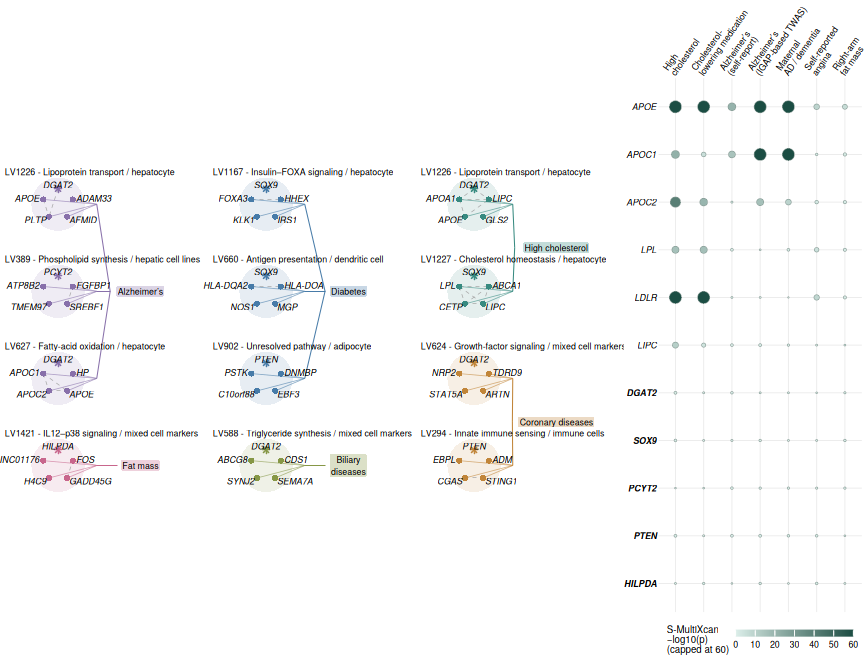

In [11]:
source(here("scripts/panels/fig3_crispr.R"))
print(plot_I)


## Assemble and save

fig3: 180 x 170 mm -> /home/msubirana/Documents/pivlab/clamp-analyses-archs4_panel/output/99_panels/fig3


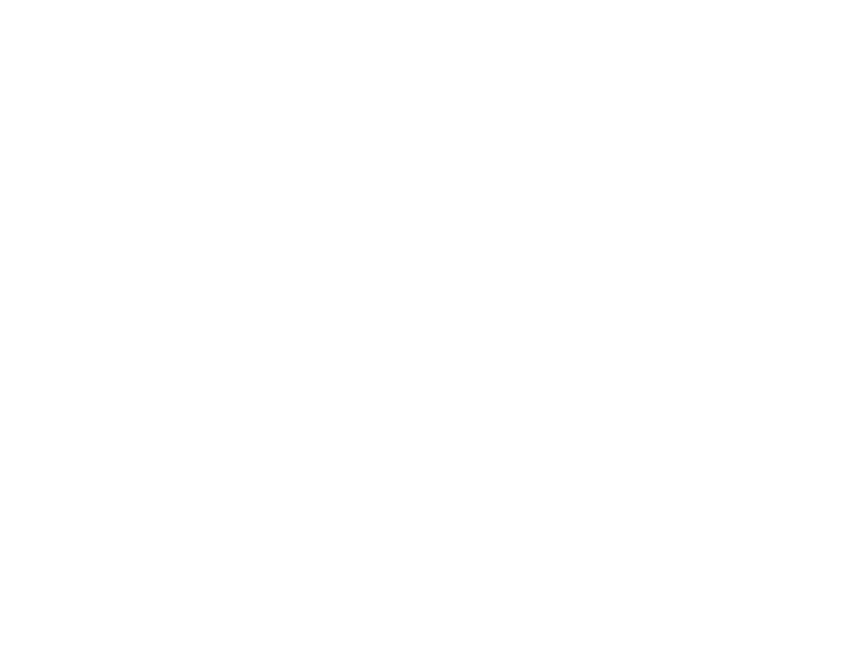

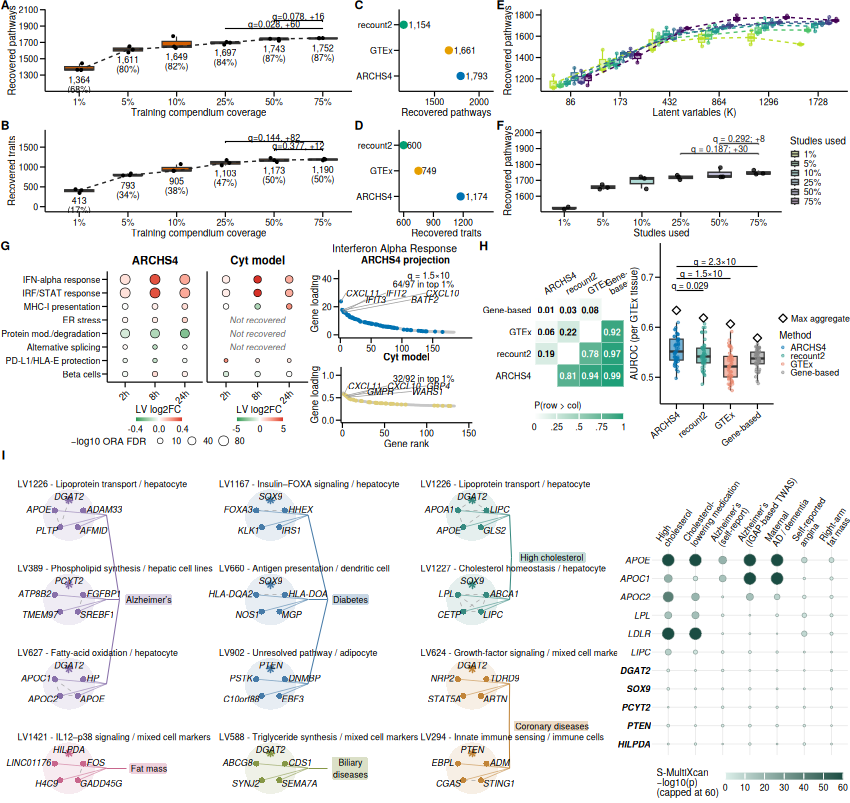

In [12]:
left_AB <- plot_grid(add_tag(plot_A, "A"), add_tag(plot_B, "B"), ncol = 1)
left_CD <- plot_grid(add_tag(plot_C, "C"), add_tag(plot_D, "D"), ncol = 1)
left_EF <- plot_grid(add_tag(plot_E, "E"), add_tag(plot_F, "F"), ncol = 1)
row1 <- plot_grid(left_AB, left_CD, left_EF,
                  nrow = 1, rel_widths = c(2.5, 1, 2.5))
# Keep the G/H subplots in one compact band rather than nesting G and H
# as two wide composites. H2 retains its paired ARCHS4/local facets.
row2 <- plot_grid(
  add_tag(plot_H1, "G"), plot_H2,
  add_tag(plot_G1, "H"), plot_G2, legend_G,
  nrow = 1, rel_widths = c(2.3, 1.25, 1.1, 1.1, .55)
)
row3 <- add_tag(plot_I, "I")

# Give the G/H and I bands more vertical space than the A--F overview band.
fig3 <- plot_grid(row1, row2, row3, ncol = 1, rel_heights = c(0.30, 0.26, 0.44))

# Enforce final-size typography on every nested text grob, including helper plots.
# ggplot text uses mm internally; grob font sizes here are points.
clamp_fonts <- function(g) {
  if (inherits(g, "text")) {
    fs <- g$gp$fontsize
    if (is.null(fs)) fs <- 5
    g$gp$fontsize <- pmax(5, pmin(7, fs))
    g$gp$fontfamily <- "Helvetica"
  }
  if (!is.null(g$grobs)) g$grobs <- lapply(g$grobs, clamp_fonts)
  if (!is.null(g$children)) for (i in seq_along(g$children)) g$children[[i]] <- clamp_fonts(g$children[[i]])
  g
}
fig3 <- clamp_fonts(grid::forceGrob(ggplotGrob(fig3)))

out_dir <- here("output/99_panels/fig3")
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# Export the remaining displayed data alongside the new B/D/G/H/I tables.
for (nm in c("arch_sum", "fraction_totals", "comparisons_A", "cross_sum_c", "sat", "sat_lastk"))
  fwrite(get(nm),file.path(source_dir,paste0(nm,".csv")))
fwrite(comparisons_H1,file.path(source_dir,"H_curated_mechanisms.csv"))
writeLines(c("Figure 3: 180 x 170 mm; minimum text 5 pt.",
             "B: 00_coverage/coverage_trait_recovery.csv; CLAMPbase. D: final_trait_recovery.csv; CLAMPbase.",
             "G: 02_drug_diseases_canonical/three_model_comparison/data; four methods, 49 tissues.",
             "I: 04_crispercas/02_network/figures; all twelve module instances and 77 TWAS entries.",
             "F: only 75% versus 25% and 50% displayed; original full-family BH correction retained."),
           file.path(source_dir,"README.txt"))

raw_pdf <- tempfile(fileext = ".pdf")
ggsave(raw_pdf, fig3, width = FIG_W, height = FIG_H, units = "mm",
       device = cairo_pdf, bg = "white", limitsize = FALSE)

if (nzchar(Sys.which("gs"))) {
  exact_pdf <- tempfile(fileext = ".pdf")
  pdf_w_pt <- FIG_W / 25.4 * 72
  pdf_h_pt <- FIG_H / 25.4 * 72
  gs_status <- system2("gs", c(
    "-q", "-dNOPAUSE", "-dBATCH", "-sDEVICE=pdfwrite",
    sprintf("-dDEVICEWIDTHPOINTS=%.6f", pdf_w_pt),
    sprintf("-dDEVICEHEIGHTPOINTS=%.6f", pdf_h_pt),
    "-dFIXEDMEDIA", "-dPDFFitPage",
    paste0("-sOutputFile=", exact_pdf), raw_pdf
  ))
  stopifnot(gs_status == 0L)
  file.copy(exact_pdf, file.path(out_dir, "fig3.pdf"), overwrite = TRUE)
  unlink(exact_pdf)
} else {
  file.copy(raw_pdf, file.path(out_dir, "fig3.pdf"), overwrite = TRUE)
}
unlink(raw_pdf)

ggsave(file.path(out_dir, "fig3.svg"), fig3, width = FIG_W, height = FIG_H,
       units = "mm", device = svglite::svglite, bg = "white", limitsize = FALSE)
ggsave(file.path(out_dir, "fig3.png"), fig3, width = FIG_W, height = FIG_H,
       units = "mm", dpi = 600, device = ragg::agg_png, bg = "white", limitsize = FALSE)

cat(sprintf("fig3: %.0f x %.0f mm -> %s\n", FIG_W, FIG_H, out_dir))
options(repr.plot.width = FIG_W / 25.4, repr.plot.height = FIG_H / 25.4)
grid::grid.newpage()
grid::grid.draw(fig3)
